<a href="https://colab.research.google.com/github/fabiankmroh/aistudy/blob/master/binary_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch

## Step 1: Data Collection

In [ ]:
# case 1
N = 20
random0 = torch.randn(int(N/2), 1)
random5 = torch.randn(int(N/2), 1) + 5

class1_data = torch.hstack([random0, random5])
class2_data = torch.hstack([random5, random0])
class1_label = torch.ones(int(N/2), 1)
class2_label = torch.zeros(int(N/2), 1)

X = torch.vstack([class1_data, class2_data])
y = torch.vstack([class1_label, class2_label])

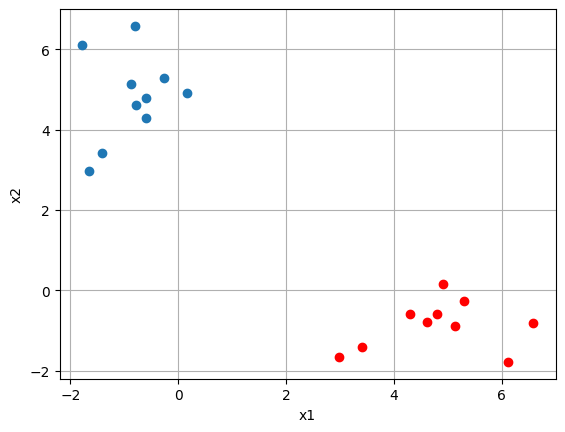

In [ ]:
import matplotlib.pyplot as plt

plt.plot(class1_data[:, 0], class1_data[:, 1], 'o')
plt.plot(class2_data[:, 0], class2_data[:, 1], 'ro')

plt.xlabel('x1')
plt.ylabel('x2')
plt.grid()

## Step 2: Create Model

In [ ]:
from torch import nn

In [ ]:
class MLP(nn.Module):
  def __init__(self):
    super().__init__()

    self.linear = nn.Sequential(
        nn.Linear(2, 100),
        nn.Sigmoid(),

        nn.Linear(100, 1),
        nn.Sigmoid()
    )

  def forward(self, x):
    x = self.linear(x)
    return x

In [ ]:
model = MLP()
print(model)

MLP(
  (linear): Sequential(
    (0): Linear(in_features=2, out_features=100, bias=True)
    (1): Sigmoid()
    (2): Linear(in_features=100, out_features=1, bias=True)
    (3): Sigmoid()
  )
)


In [ ]:
input = torch.randn(5, 2)
print("Input: ", input)
print(model(input).shape)

Input:  tensor([[ 0.5596, -1.3880],
        [ 0.8546,  0.9248],
        [-0.0720, -1.6562],
        [-0.8460,  0.5195],
        [-0.1694, -0.7706]])
torch.Size([5, 1])


## Step 3: Train Model

In [ ]:
from torch import optim

In [ ]:
LR = 1e-2
EPOCH = 30

In [ ]:
optimizer = optim.Adam(model.parameters(), lr = LR)

In [ ]:
criterion = nn.BCELoss()

In [ ]:
loss_history = []
grad_history = []

In [ ]:
model.train() # Change to Train Mode

MLP(
  (linear): Sequential(
    (0): Linear(in_features=2, out_features=100, bias=True)
    (1): Sigmoid()
    (2): Linear(in_features=100, out_features=1, bias=True)
    (3): Sigmoid()
  )
)

In [ ]:
for ep in range(EPOCH):
  # Inference
  y_hat = model(X)

  # Loss
  loss = criterion(y_hat, y)

  # Prev Weights
  prev = model.linear[0].weight.detach().clone()

  # Update
  optimizer.zero_grad() # Reset to Prevent Gradient Piling
  loss.backward() # Backprop
  optimizer.step() # Update Weights

  # Print Loss
  loss_history += [loss.item()]
  print(f"Epoch: {ep+1} / Train Loss: {loss.item():.4f}")
  print("-" * 20)

Epoch: 1 / Train Loss: 0.6580
--------------------
Epoch: 2 / Train Loss: 0.5353
--------------------
Epoch: 3 / Train Loss: 0.4313
--------------------
Epoch: 4 / Train Loss: 0.3452
--------------------
Epoch: 5 / Train Loss: 0.2749
--------------------
Epoch: 6 / Train Loss: 0.2182
--------------------
Epoch: 7 / Train Loss: 0.1728
--------------------
Epoch: 8 / Train Loss: 0.1367
--------------------
Epoch: 9 / Train Loss: 0.1083
--------------------
Epoch: 10 / Train Loss: 0.0860
--------------------
Epoch: 11 / Train Loss: 0.0686
--------------------
Epoch: 12 / Train Loss: 0.0551
--------------------
Epoch: 13 / Train Loss: 0.0445
--------------------
Epoch: 14 / Train Loss: 0.0363
--------------------
Epoch: 15 / Train Loss: 0.0298
--------------------
Epoch: 16 / Train Loss: 0.0247
--------------------
Epoch: 17 / Train Loss: 0.0206
--------------------
Epoch: 18 / Train Loss: 0.0174
--------------------
Epoch: 19 / Train Loss: 0.0148
--------------------
Epoch: 20 / Train Los

In [ ]:
print(criterion(y_hat, y)) # Criterion: Binary Cross Entroy (BCE)
print(torch.sum(-torch.log(y_hat ** y  *  (1-y_hat) ** (1-y))) / N)

tensor(0.0041, grad_fn=<BinaryCrossEntropyBackward0>)
tensor(0.0041, grad_fn=<DivBackward0>)


In [ ]:
print(criterion(torch.tensor([0.]), torch.tensor([1.])))

tensor(100.)


ValueError: x and y must have same first dimension, but have shapes (30,) and (0,)

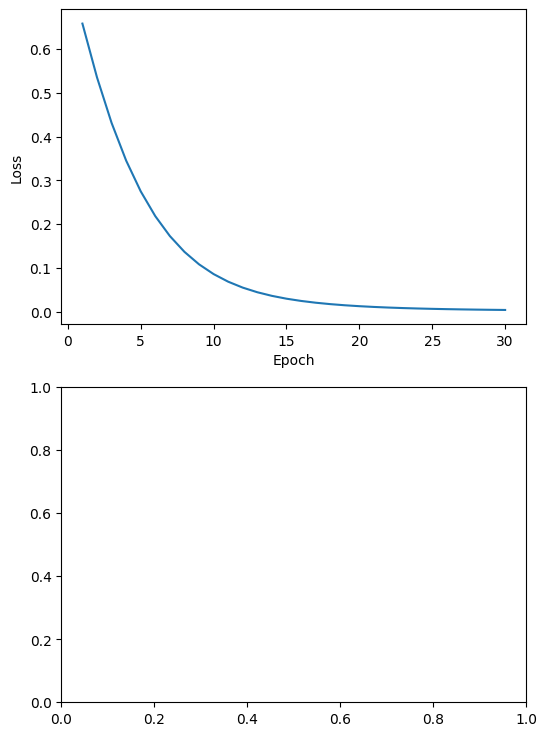

In [ ]:
plt.figure(figsize = (6,9))
plt.subplot(2,1,1)

plt.plot(range(1, EPOCH+1), loss_history)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(2,1,2)
plt.plot(range(1, EPOCH + 1), grad_history)
plt.xlabel("Epoch")
plt.ylabel("Grad Size")

## Step 4: Model Test

In [ ]:
x1_test = torch.linspace(-2, 2, 30)
x2_test = torch.linspace(-2, 2, 30)

X1_test, X2_test = torch.meshgrid(x1_test, x2_test)
X_test = torch.cat([X1_test.unsqueeze(dim = 2), X2_test.unsqueeze(dim = 2)], dim = 2)

/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [ ]:
model.eval()
with torch.no_grad():
  y_hat = model(X_test)

Y_hat = y_hat.squeeze()

Text(0.5, 0.5, 'x2')

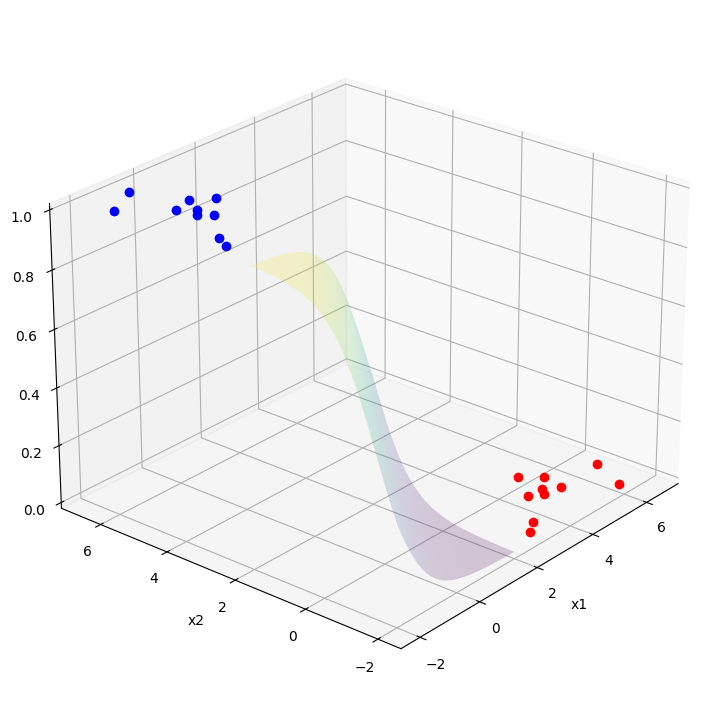

In [ ]:
plt.figure(figsize = [10, 9])
ax = plt.axes(projection = '3d')
ax.view_init(elev = 25, azim = -140)
ax.plot_surface(X1_test, X2_test, Y_hat.numpy(), cmap = "viridis", alpha = 0.2)

plt.plot(class1_data[:, 0], class1_data[:, 1], class1_label.squeeze(), 'bo')
plt.plot(class2_data[:, 0], class2_data[:, 1], class2_label.squeeze(), 'ro')

plt.xlabel('x1')
plt.ylabel('x2')

NameError: name 'class_data' is not defined

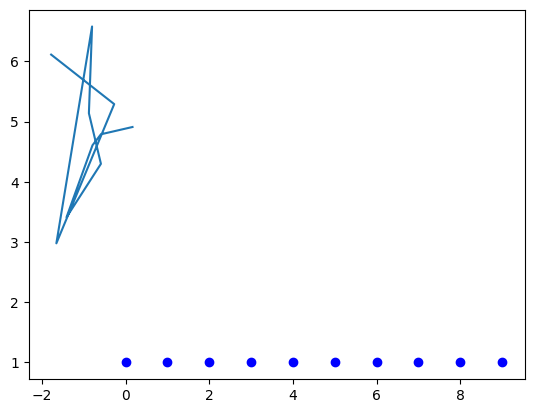

## Hyperparameter Tuning
If `n parameter` increases,
- `Learning Rate` Down: Stability Purposes -> Prevent High-Dimensional Overshooting
- `Batch Size` Up (only when Distributed Training in Big Tech)

In [ ]:
class MLP(nn.Module):
  super().__init__() # nn.Module Call

  self.linear = nn.Sequential(
      nn.Linear(2, 100),
      nn.Sigmoid(),

      *[i for _ in range(10) for i in [nn.Linear(100, 100), nn.Sigmoid()]]
  )